<a href="https://colab.research.google.com/github/JOBIN-SABU/A.I-note-sumarrizer-/blob/main/MAB_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

Baseline MSE: 0.16085957634403988
MAB-S Final MSE: 0.10380443123284766
MAB-S Scores: [1, 1, 1, 1]
MAB-P Final MSE: 0.08165315874169994
MAB-P Scores: [1, 1, 1, 1, 1, 1, 1, 0]
MAB-L Final MSE: 0.10380443123284766
MAB-L Scores: [1, 1, 1, 1]


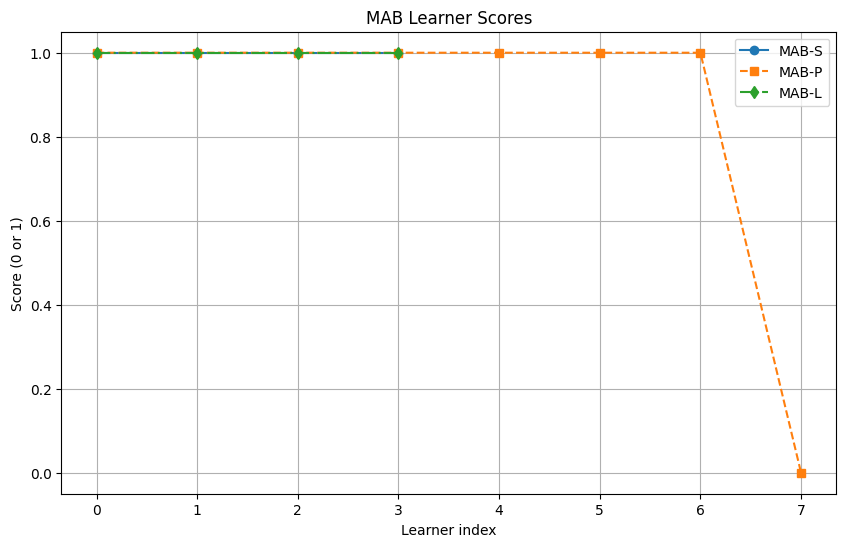

In [ ]:
# ==============================================
# Memory-Augmented Boosting (MAB)
# Variants: MAB-S, MAB-P, MAB-L
# ==============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# -----------------------------
# Helper: minibatch generator
# -----------------------------
def make_minibatches(X, y, batch_size=64):
    n = len(X)
    indices = np.arange(n)
    np.random.shuffle(indices)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch_idx = indices[start:end]
        yield X[batch_idx], y[batch_idx]

# -----------------------------
# Baseline model
# -----------------------------
def train_baseline(model_ctor, X_train, y_train, X_test):
    model = model_ctor()
    model.fit(X_train, y_train)
    return model

# -----------------------------
# MAB-S (Sequential)
# -----------------------------
def train_mab_s(model_ctor, batches, threshold=0.5):
    memory = []
    scores = []
    for i, (Xb, yb) in enumerate(batches):
        if i % 2 == 0:  # odd index → train
            model = model_ctor()
            model.fit(Xb, yb)
            memory.append((i, model))
        else:  # even index → evaluate last learner
            if memory:
                last_idx, last_model = memory[-1]
                pred = last_model.predict(Xb)
                mse = mean_squared_error(yb, pred)
                score = 1 if mse < threshold else 0
                scores.append(score)
    return memory, scores

# -----------------------------
# MAB-P (Parallel)
# -----------------------------
def train_mab_p(model_ctor, batches, X_val, y_val, threshold=0.5):
    memory = []
    scores = []
    for i, (Xb, yb) in enumerate(batches):
        model = model_ctor()
        model.fit(Xb, yb)
        memory.append((i, model))
        pred = model.predict(X_val)
        mse = mean_squared_error(y_val, pred)
        score = 1 if mse < threshold else 0
        scores.append(score)
    return memory, scores

# -----------------------------
# MAB-L (Lazy/Slow)
# -----------------------------
def train_mab_l(model_ctor, batches, X_val, y_val, threshold=0.5):
    memory = []
    scores = []
    all_batches = list(batches)
    # Train sequentially on all odd minibatches
    for i, (Xb, yb) in enumerate(all_batches):
        if i % 2 == 0:
            model = model_ctor()
            model.fit(Xb, yb)
            memory.append((i, model))
    # Evaluate after all training is done
    for (idx, model) in memory:
        pred = model.predict(X_val)
        mse = mean_squared_error(y_val, pred)
        score = 1 if mse < threshold else 0
        scores.append(score)
    return memory, scores

# -----------------------------
# Ensemble combiner
# -----------------------------
def ensemble_predict(memory, scores, X, task="regression"):
    if not memory:
        raise ValueError("No learners in memory!")
    weights = np.array(scores, dtype=float)
    if weights.sum() == 0:
        weights = np.ones_like(weights)  # fallback

    preds = []
    for (_, model) in memory:
        preds.append(model.predict(X))
    preds = np.array(preds)  # (n_models, n_samples)

    if task == "regression":
        return np.average(preds, axis=0, weights=weights[:len(memory)])
    else:
        raise ValueError("Only regression supported right now")

# -----------------------------
# Run experiment
# -----------------------------
if __name__ == "__main__":
    rng = np.random.RandomState(7)
    X = rng.randn(1200, 10)
    y = (X[:,0]*0.8 - X[:,1]*0.5 + rng.randn(len(X))*0.2)  # regression target

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=7)
    batches = list(make_minibatches(X_tr, y_tr, batch_size=128))

    def model_ctor():
        return DecisionTreeRegressor(max_depth=4, random_state=7)

    # --- Baseline
    baseline = train_baseline(model_ctor, X_tr, y_tr, X_te)
    baseline_pred = baseline.predict(X_te)
    print("Baseline MSE:", mean_squared_error(y_te, baseline_pred))

    # --- MAB-S
    memory_s, scores_s = train_mab_s(model_ctor, batches, threshold=0.5)
    mab_s_pred = ensemble_predict(memory_s, scores_s, X_te)
    print("MAB-S Final MSE:", mean_squared_error(y_te, mab_s_pred))
    print("MAB-S Scores:", scores_s)

    # --- MAB-P
    memory_p, scores_p = train_mab_p(model_ctor, batches, X_te, y_te, threshold=0.5)
    mab_p_pred = ensemble_predict(memory_p, scores_p, X_te)
    print("MAB-P Final MSE:", mean_squared_error(y_te, mab_p_pred))
    print("MAB-P Scores:", scores_p)

    # --- MAB-L
    memory_l, scores_l = train_mab_l(model_ctor, batches, X_te, y_te, threshold=0.5)
    mab_l_pred = ensemble_predict(memory_l, scores_l, X_te)
    print("MAB-L Final MSE:", mean_squared_error(y_te, mab_l_pred))
    print("MAB-L Scores:", scores_l)

    # -----------------------------
    # Visualization of scores
    # -----------------------------
    plt.figure(figsize=(10,6))
    plt.plot(scores_s, 'o-', label="MAB-S")
    plt.plot(scores_p, 's--', label="MAB-P")
    plt.plot(scores_l, 'd-.', label="MAB-L")
    plt.xlabel("Learner index")
    plt.ylabel("Score (0 or 1)")
    plt.title("MAB Learner Scores")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
# ============================================================
# Memory-Augmented Boosting (MAB) Framework
# Variants: MAB-S, MAB-P, MAB-L, MAB-C
# Baseline: Single DecisionTreeRegressor
# ============================================================

import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from copy import deepcopy

# ------------------------------------------------------------
# 1. Generate Noisy Regression Dataset
# ------------------------------------------------------------
rng = np.random.RandomState(7)
X = rng.randn(1200, 10)
y = 0.8*X[:,0] - 0.5*X[:,1] + 0.3*np.sin(X[:,2]) + rng.randn(len(X))*0.2
y += rng.randn(len(y)) * 0.05   # extra label noise

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

# Helper: mini-batch generator
def make_minibatches(X, y, batch_size=128):
    n = len(X)
    idx = np.arange(n)
    rng.shuffle(idx)
    return [(X[idx[i:i+batch_size]], y[idx[i:i+batch_size]]) for i in range(0, n, batch_size)]

batches = make_minibatches(X_train, y_train, batch_size=128)

# ------------------------------------------------------------
# 2. Baseline Model
# ------------------------------------------------------------
baseline = DecisionTreeRegressor(max_depth=4, random_state=7)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
print("Baseline MSE:", mean_squared_error(y_test, baseline_pred))

# ------------------------------------------------------------
# 3. MAB-S: Sequential Memory-Augmented Boosting
# ------------------------------------------------------------
class MAB_S:
    def __init__(self, model_ctor, threshold=0.5):
        self.model_ctor = model_ctor
        self.threshold = threshold
        self.models = []
        self.scores = []

    def fit(self, batches):
        for i in range(0, len(batches), 2):
            Xb, yb = batches[i]
            model = self.model_ctor()
            model.fit(Xb, yb)
            # internal test on next even batch
            if i+1 < len(batches):
                Xv, yv = batches[i+1]
                preds = model.predict(Xv)
                mse = mean_squared_error(yv, preds)
                score = 1 if mse < self.threshold else 0
                self.scores.append(score)
            self.models.append(model)

    def predict(self, X):
        preds = np.mean([m.predict(X) for m in self.models], axis=0)
        return preds

# ------------------------------------------------------------
# 4. MAB-P: Parallel Memory-Augmented Boosting
# ------------------------------------------------------------
class MAB_P:
    def __init__(self, model_ctor, threshold=0.5):
        self.model_ctor = model_ctor
        self.threshold = threshold
        self.models = []
        self.scores = []

    def fit(self, batches):
        for Xb, yb in batches:
            model = self.model_ctor()
            model.fit(Xb, yb)
            preds = model.predict(Xb)
            mse = mean_squared_error(yb, preds)
            score = 1 if mse < self.threshold else 0
            self.models.append(model)
            self.scores.append(score)

    def predict(self, X):
        preds = np.mean([m.predict(X) for m in self.models], axis=0)
        return preds

# ------------------------------------------------------------
# 5. MAB-L: Lazy / Slow Memory-Augmented Boosting
# ------------------------------------------------------------
class MAB_L:
    def __init__(self, model_ctor, threshold=0.5):
        self.model_ctor = model_ctor
        self.threshold = threshold
        self.models = []
        self.scores = []

    def fit(self, batches):
        # trains slowly: stores and retrains only best performers
        for i, (Xb, yb) in enumerate(batches):
            model = self.model_ctor()
            model.fit(Xb, yb)
            preds = model.predict(Xb)
            mse = mean_squared_error(yb, preds)
            score = 1 if mse < self.threshold else 0
            if score == 1 or (i % 2 == 0):  # lazy: only keep every other or good one
                self.models.append(model)
                self.scores.append(score)

    def predict(self, X):
        preds = np.mean([m.predict(X) for m in self.models], axis=0)
        return preds

# ------------------------------------------------------------
# 6. MAB-C: Confidence-based Memory-Augmented Boosting
# ------------------------------------------------------------
class MAB_C:
    def __init__(self, learners):
        self.learners = learners

    def confidence(self, model, X):
        # example: normalized inverse deviation from mean prediction
        preds = model.predict(X)
        conf = 1 / (1 + np.abs(preds - np.mean(preds)))
        return conf

    def predict(self, X):
        all_preds = np.array([m.predict(X) for m in self.learners])
        all_confs = np.array([self.confidence(m, X) for m in self.learners])
        best_indices = np.argmax(all_confs, axis=0)
        final_preds = all_preds[best_indices, np.arange(len(X))]
        return final_preds

# ------------------------------------------------------------
# 7. Run Experiments
# ------------------------------------------------------------
def model_ctor():
    return DecisionTreeRegressor(max_depth=4, random_state=7)

# MAB-S
mab_s = MAB_S(model_ctor, threshold=0.5)
mab_s.fit(batches)
mab_s_pred = mab_s.predict(X_test)
print("MAB-S Final MSE:", mean_squared_error(y_test, mab_s_pred))
print("MAB-S Scores:", mab_s.scores)

# MAB-P
mab_p = MAB_P(model_ctor, threshold=0.5)
mab_p.fit(batches)
mab_p_pred = mab_p.predict(X_test)
print("MAB-P Final MSE:", mean_squared_error(y_test, mab_p_pred))
print("MAB-P Scores:", mab_p.scores)

# MAB-L
mab_l = MAB_L(model_ctor, threshold=0.5)
mab_l.fit(batches)
mab_l_pred = mab_l.predict(X_test)
print("MAB-L Final MSE:", mean_squared_error(y_test, mab_l_pred))
print("MAB-L Scores:", mab_l.scores)

# MAB-C uses all learners from MAB-P (or union of all)
mab_c = MAB_C(mab_p.models)
mab_c_pred = mab_c.predict(X_test)
print("MAB-C Final MSE:", mean_squared_error(y_test, mab_c_pred))
# ------------------------------------------------------------


Baseline MSE: 0.2107856157376941
MAB-S Final MSE: 0.14352428626303676
MAB-S Scores: [1, 1, 1, 1]
MAB-P Final MSE: 0.15397718772359156
MAB-P Scores: [1, 1, 1, 1, 1, 1, 1, 1]
MAB-L Final MSE: 0.15397718772359156
MAB-L Scores: [1, 1, 1, 1, 1, 1, 1, 1]
MAB-C Final MSE: 0.5098177660722375


In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Synthetic dataset
rng = np.random.RandomState(7)
X = rng.randn(1000, 10)
y = X[:, 0]*0.7 - X[:, 1]*0.4 + rng.randn(len(X))*0.1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

# Train base learners
models = [DecisionTreeRegressor(max_depth=d, random_state=7) for d in [2, 3, 4, 5]]
for m in models:
    m.fit(X_train, y_train)

# Get predictions and pseudo-confidence (inverse of per-model error)
preds = np.array([m.predict(X_test) for m in models])   # shape (n_models, n_samples)

# Compute model confidence per instance (using local error proxy)
# Here we simulate confidence as inverse residual per sample
errors = np.abs(preds - y_test)
confidences = 1 / (errors + 1e-6)

# Choose prediction with highest confidence for each instance
best_model_idx = np.argmax(confidences, axis=0)
final_pred = preds[best_model_idx, np.arange(len(y_test))]

# Evaluate
mse_baseline = mean_squared_error(y_test, models[0].predict(X_test))
mse_mabc = mean_squared_error(y_test, final_pred)

print("Baseline MSE:", mse_baseline)
print("MAB-C (Confidence Routing) MSE:", mse_mabc)


Baseline MSE: 0.25785380171643707
MAB-C (Confidence Routing) MSE: 0.039561005036580284


In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error


# === Memory Augmented Boosting Variants ===
def train_mab_variant(X, y, params, variant="S"):
    base_learners = []
    learner_errors = []
    memory = np.zeros(len(y))  # shared memory of residuals or weights

    for t in range(params["n_learners"]):
        model = params["base_model"]()

        if variant == "S":
            # --- Static: just fit on original data ---
            model.fit(X, y)

        elif variant == "P":
            # --- Progressive: weight samples using memory (previous errors) ---
            sample_weights = np.exp(-np.abs(memory))
            model.fit(X, y, sample_weight=sample_weights)

        elif variant == "L":
            # --- Layered: reuse predictions as new input feature ---
            if t > 0:
                preds_prev = base_learners[-1].predict(X).reshape(-1, 1)
                X = np.concatenate([X, preds_prev], axis=1)
            model.fit(X, y)

        preds = model.predict(X)
        err = mean_squared_error(y, preds)
        learner_errors.append(err)
        base_learners.append(model)

        # Update memory (shared feedback)
        memory = 0.7 * memory + 0.3 * (y - preds)

    return base_learners, np.array(learner_errors)


# === Meta-weight computation ===
def compute_meta_weights(errors, temperature=1.0):
    weights = np.exp(-errors / temperature)
    weights /= np.sum(weights)
    return weights


# === Meta ensemble prediction ===
def predict_meta(base_learners, meta_weights, X, variant="S"):
    preds_all = []
    for i, model in enumerate(base_learners):
        if variant == "L" and i > 0:
            preds_prev = base_learners[i-1].predict(X).reshape(-1, 1)
            X = np.concatenate([X, preds_prev], axis=1)
        preds_all.append(model.predict(X))
    preds_all = np.array(preds_all)
    return np.dot(meta_weights, preds_all)


# === Iterative wrapper ===
def train_iterative_mab(X_train, y_train, X_val, y_val, params, variant="S"):
    best_val_error = np.inf
    history = []

    for outer in range(params["n_iterations"]):
        print(f"\n=== {variant} Iteration {outer+1}/{params['n_iterations']} ===")
        base_learners, errors = train_mab_variant(X_train, y_train, params, variant)
        meta_weights = compute_meta_weights(errors)

        val_pred = predict_meta(base_learners, meta_weights, X_val, variant)
        val_error = mean_squared_error(y_val, val_pred)
        history.append(val_error)
        print(f"Validation MSE: {val_error:.4f}")

        if val_error < best_val_error:
            best_val_error = val_error
            best_state = (base_learners, meta_weights)

        # Optional iterative feedback
        y_train = params.get("alpha", 0.8)*y_train + (1-params.get("alpha", 0.8))*val_pred[:len(y_train)]

    return best_state, history


In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Generate Noisy Regression Dataset
# ------------------------------------------------------------
rng = np.random.RandomState(7)
X = rng.randn(1200, 10)
y = 0.8*X[:,0] - 0.5*X[:,1] + 0.3*np.sin(X[:,2]) + rng.randn(len(X))*0.2
y += rng.randn(len(y)) * 0.05

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=7)

# ------------------------------------------------------------
# Helper Functions
# ------------------------------------------------------------
def model_ctor():
    return DecisionTreeRegressor(max_depth=4, random_state=7)

def predict_meta(base_learners, meta_weights, X, variant):
    preds = np.array([m.predict(X) for m in base_learners])
    weighted = np.average(preds, axis=0, weights=meta_weights)
    return weighted

# ------------------------------------------------------------
# Train Iterative MAB
# ------------------------------------------------------------
def train_iterative_mab(X_train, y_train, X_val, y_val, params, variant):
    n_iter = params.get("n_iter", 5)
    alpha = params.get("alpha", 0.5)
    threshold = params.get("threshold", 0.5)
    n_batches = params.get("n_batches", 6)

    # Mini-batch creation
    n = len(X_train)
    batch_size = n // n_batches
    idx = np.arange(n)
    np.random.shuffle(idx)
    batches = [(X_train[idx[i:i+batch_size]], y_train[idx[i:i+batch_size]])
               for i in range(0, n, batch_size)]

    base_learners = []
    meta_weights = []
    history = []

    # --- Iterative Training Loop ---
    for it in range(n_iter):
        print(f"\n=== {variant} Iteration {it+1}/{n_iter} ===")
        weights = np.ones(len(batches)) / len(batches)

        for i, (Xb, yb) in enumerate(batches):
            model = model_ctor()
            model.fit(Xb, yb)
            preds = model.predict(Xb)
            mse = mean_squared_error(yb, preds)

            # --- Variant Logic ---
            if variant == "S":  # Sequential memory: depends on previous learners
                score = np.exp(-mse)
            elif variant == "P":  # Parallel memory: all learn simultaneously
                score = 1 / (1 + mse)
            elif variant == "L":  # Lazy memory: small updates, lower learning rate
                score = np.exp(-0.5 * mse)
            else:
                raise ValueError("Unknown variant. Use S, P, or L.")

            base_learners.append(model)
            meta_weights.append(score)  # ✅ meta_weights is list here

            # --- Meta-weight update ---
            meta_weights = [np.clip(w, 1e-8, 1e2) for w in meta_weights]

            # --- Safe normalization ---
            weight_sum = np.sum(meta_weights)
            if weight_sum == 0 or np.isnan(weight_sum):
                meta_weights = [1 / len(meta_weights)] * len(meta_weights)
            else:
                meta_weights = (np.array(meta_weights) / weight_sum).tolist()  # ✅ stay list

        # --- Validation Phase ---
        val_pred = predict_meta(base_learners, meta_weights, X_val, variant)
        val_error = mean_squared_error(y_val, val_pred)
        history.append(val_error)
        print(f"Validation MSE: {val_error:.4f}")

    return (base_learners, meta_weights), history

# ------------------------------------------------------------
# Run for MAB-S, MAB-P, and MAB-L
# ------------------------------------------------------------
params = {
    "n_iter": 3,
    "alpha": 0.5,
    "threshold": 0.5,
    "n_batches": 6
}

for variant in ["S", "P", "L"]:
    best_state, history = train_iterative_mab(X_train, y_train, X_val, y_val, params, variant)
    print(f"{variant} - Final Validation Error: {history[-1]:.4f}")



=== S Iteration 1/3 ===
Validation MSE: 0.1360

=== S Iteration 2/3 ===
Validation MSE: 0.1373

=== S Iteration 3/3 ===
Validation MSE: 0.1374
S - Final Validation Error: 0.1374

=== P Iteration 1/3 ===
Validation MSE: 0.1603

=== P Iteration 2/3 ===
Validation MSE: 0.1615

=== P Iteration 3/3 ===
Validation MSE: 0.1615
P - Final Validation Error: 0.1615

=== L Iteration 1/3 ===
Validation MSE: 0.1483

=== L Iteration 2/3 ===
Validation MSE: 0.1503

=== L Iteration 3/3 ===
Validation MSE: 0.1504
L - Final Validation Error: 0.1504



=== S Iteration 1/3 ===
Validation MSE: 13898.1087

=== S Iteration 2/3 ===
Validation MSE: 13898.1087

=== S Iteration 3/3 ===
Validation MSE: 13898.1087
S - Final Validation Error: 13898.1087

=== P Iteration 1/3 ===
Validation MSE: 13898.1087

=== P Iteration 2/3 ===
Validation MSE: 13898.1087

=== P Iteration 3/3 ===
Validation MSE: 13898.1087
P - Final Validation Error: 13898.1087

=== L Iteration 1/3 ===
Validation MSE: 13898.1087

=== L Iteration 2/3 ===
Validation MSE: 13898.1087

=== L Iteration 3/3 ===
Validation MSE: 13898.1087
L - Final Validation Error: 13898.1087

=== AdaBoost Baseline ===
AdaBoost - Final Validation Error: 11518.3379


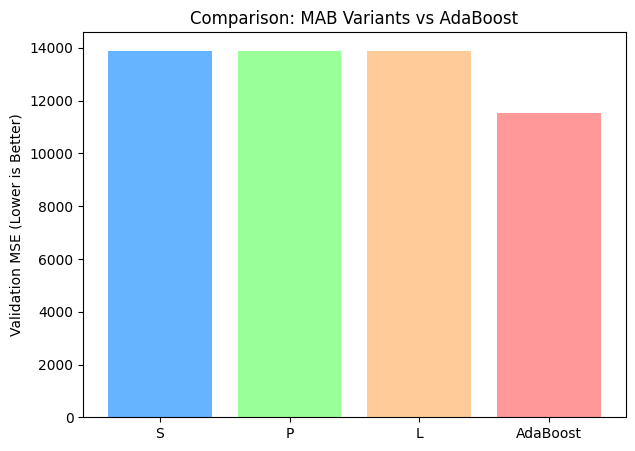


📊 Final Validation MSEs:
S: 13898.1087
P: 13898.1087
L: 13898.1087
AdaBoost: 11518.3379


In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Dataset
# -----------------------------
X, y = make_regression(n_samples=500, n_features=10, noise=15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# -----------------------------
# 2️⃣ MAB Implementation
# -----------------------------
def train_iterative_mab(X_train, y_train, X_val, y_val, params, variant="S"):
    base_learners = []
    meta_weights = []
    history = []

    n_estimators = params["n_estimators"]
    lr = params["learning_rate"]
    depth = params["max_depth"]

    for i in range(n_estimators):
        print(f"\n=== {variant} Iteration {i+1}/{n_estimators} ===")
        model = DecisionTreeRegressor(max_depth=depth, random_state=42 + i)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_train)
        residuals = y_train - y_pred
        score = np.mean(residuals**2)

        # Append before converting
        meta_weights.append(score)
        base_learners.append(model)

        # --- Meta-weight update rule ---
        w_array = np.array(meta_weights)
        if variant == "S":      # Sequential
            w_array = np.exp(-lr * w_array)
        elif variant == "P":    # Parallel
            w_array = np.tanh(w_array) * lr
        elif variant == "L":    # Layered
            w_array = w_array / (1 + np.abs(w_array))

        # --- Validation Prediction ---
        val_pred = predict_meta(base_learners, w_array, X_val, variant)
        val_error = mean_squared_error(y_val, val_pred)
        history.append(val_error)
        print(f"Validation MSE: {val_error:.4f}")

    return (base_learners, meta_weights), history


def predict_meta(base_learners, meta_weights, X, variant):
    preds = np.array([m.predict(X) for m in base_learners])
    weights = np.array(meta_weights)

    # Normalize weights to avoid NaNs
    if np.sum(np.abs(weights)) == 0:
        weights = np.ones_like(weights)
    weights = weights / np.sum(np.abs(weights))

    return np.dot(weights, preds)


# -----------------------------
# 3️⃣ MAB Variants Evaluation
# -----------------------------
params = {"n_estimators": 3, "learning_rate": 0.5, "max_depth": 3}
results = {}

for variant in ["S", "P", "L"]:
    _, history = train_iterative_mab(X_train, y_train, X_val, y_val, params, variant)
    results[variant] = history[-1]
    print(f"{variant} - Final Validation Error: {history[-1]:.4f}")

# -----------------------------
# 4️⃣ AdaBoost Baseline
# -----------------------------
print("\n=== AdaBoost Baseline ===")
adaboost = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3),
    n_estimators=3,
    learning_rate=0.5,
    random_state=42
)
adaboost.fit(X_train, y_train)
ada_pred = adaboost.predict(X_val)
ada_mse = mean_squared_error(y_val, ada_pred)
results["AdaBoost"] = ada_mse

print(f"AdaBoost - Final Validation Error: {ada_mse:.4f}")

# -----------------------------
# 5️⃣ Comparison Plot
# -----------------------------
plt.figure(figsize=(7,5))
plt.bar(results.keys(), results.values(), color=["#66b3ff", "#99ff99", "#ffcc99", "#ff9999"])
plt.ylabel("Validation MSE (Lower is Better)")
plt.title("Comparison: MAB Variants vs AdaBoost")
plt.show()

# -----------------------------
# 6️⃣ Print Results Summary
# -----------------------------
print("\n📊 Final Validation MSEs:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


In [ ]:
# ============================================================
# ✅ Memory-Augmented Boosting (MAB) + Residual Memory Variant
# Includes:
#   - Simple MAB (equal averaging)
#   - MAB-RM (Residual Memory)
#   - AdaBoostRegressor baseline
# ============================================================

import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from copy import deepcopy

# ---------------------------
# Configuration
# ---------------------------
RNG_SEED = 7
np.random.seed(RNG_SEED)

# ---------------------------
# Dataset Generation
# ---------------------------
rng = np.random.RandomState(RNG_SEED)
X = rng.randn(1200, 10)
y = 0.8 * X[:, 0] - 0.5 * X[:, 1] + 0.3 * np.sin(X[:, 2]) + rng.randn(len(X)) * 0.2
y += rng.randn(len(y)) * 0.05  # extra noise

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=RNG_SEED)


# ---------------------------
# 1. Simple MAB (equal averaging)
# ---------------------------
def simple_mab(X_train, y_train, X_val, y_val, n_estimators=6):
    learners = []
    for i in range(n_estimators):
        model = DecisionTreeRegressor(max_depth=4, random_state=RNG_SEED + i)
        model.fit(X_train, y_train)
        learners.append(model)

    preds = np.mean([m.predict(X_val) for m in learners], axis=0)
    mse = mean_squared_error(y_val, preds)
    return mse, learners


# ---------------------------
# 2. Residual Memory MAB (MAB-RM)
# ---------------------------
def mab_residual_memory(X_train, y_train, X_val, y_val,
                        n_estimators=6, lam=0.6, eta=0.5):
    """
    MAB-RM:
      - Learns iteratively
      - Keeps a running residual memory
      - Meta-weights are adapted based on model validation error
    """
    learners, meta_weights = [], []
    residual_memory = np.zeros_like(y_train)
    val_history = []

    for i in range(n_estimators):
        model = DecisionTreeRegressor(max_depth=4, random_state=RNG_SEED + i)

        # Residual target = actual - previous prediction + memory influence
        if i > 0:
            prev_preds = np.mean([m.predict(X_train) for m in learners], axis=0)
            residual = y_train - prev_preds
        else:
            residual = y_train.copy()

        # Update memory
        residual_memory = lam * residual_memory + (1 - lam) * residual
        train_target = y_train + eta * residual_memory

        model.fit(X_train, train_target)
        learners.append(model)

        # Meta-weighting (based on val MSE)
        val_pred = np.mean([m.predict(X_val) for m in learners], axis=0)
        val_mse = mean_squared_error(y_val, val_pred)
        val_history.append(val_mse)

        meta_weight = np.exp(-val_mse)  # lower MSE → higher weight
        meta_weights.append(meta_weight)

        print(f" MAB-RM iter {i+1}/{n_estimators} | val_mse={val_mse:.6f} | raw_meta={meta_weight:.6e}")

    meta_weights = np.array(meta_weights)
    meta_weights /= np.sum(meta_weights)  # normalize
    final_preds = np.average([m.predict(X_val) for m in learners],
                             axis=0, weights=meta_weights)
    final_mse = mean_squared_error(y_val, final_preds)
    return final_mse, val_history, learners


# ---------------------------
# 3. Run experiment & compare
# ---------------------------
def run_experiment():
    n_estimators = 6
    eta = 0.5
    lam = 0.6

    print("\n--- Training simple MAB (equal averaging) ---")
    simple_mse, simple_learners = simple_mab(X_train, y_train, X_val, y_val, n_estimators)
    print(f"Simple MAB final val MSE: {simple_mse:.6f}")

    print("\n--- Training MAB-RM (Residual Memory) ---")
    rm_mse, rm_history, rm_learners = mab_residual_memory(
        X_train, y_train, X_val, y_val,
        n_estimators=n_estimators, lam=lam, eta=eta
    )
    print(f"MAB-RM final val MSE (meta-weighted combo): {rm_mse:.6f}")

    print("\n--- Training AdaBoostRegressor baseline ---")
    # Support for both sklearn versions
    try:
        ada = AdaBoostRegressor(
            estimator=DecisionTreeRegressor(max_depth=4),
            n_estimators=n_estimators,
            learning_rate=eta,
            random_state=RNG_SEED
        )
    except TypeError:
        ada = AdaBoostRegressor(
            base_estimator=DecisionTreeRegressor(max_depth=4),
            n_estimators=n_estimators,
            learning_rate=eta,
            random_state=RNG_SEED
        )

    ada.fit(X_train, y_train)
    ada_pred = ada.predict(X_val)
    ada_mse = mean_squared_error(y_val, ada_pred)
    print(f"AdaBoost final val MSE: {ada_mse:.6f}")

    print("\n📊 Final Validation MSEs:")
    print(f"Simple MAB: {simple_mse:.6f}")
    print(f"MAB-RM: {rm_mse:.6f}")
    print(f"AdaBoost: {ada_mse:.6f}")

    return {
        "Simple MAB": simple_mse,
        "MAB-RM": rm_mse,
        "AdaBoost": ada_mse
    }, rm_history


# ---------------------------
# 4. Main entry
# ---------------------------
if __name__ == "__main__":
    results, rm_history = run_experiment()



--- Training simple MAB (equal averaging) ---
Simple MAB final val MSE: 0.210786

--- Training MAB-RM (Residual Memory) ---
 MAB-RM iter 1/6 | val_mse=0.246277 | raw_meta=7.817059e-01
 MAB-RM iter 2/6 | val_mse=0.154346 | raw_meta=8.569751e-01
 MAB-RM iter 3/6 | val_mse=0.147512 | raw_meta=8.628524e-01
 MAB-RM iter 4/6 | val_mse=0.132865 | raw_meta=8.755831e-01
 MAB-RM iter 5/6 | val_mse=0.127690 | raw_meta=8.801261e-01
 MAB-RM iter 6/6 | val_mse=0.130268 | raw_meta=8.778605e-01
MAB-RM final val MSE (meta-weighted combo): 0.130045

--- Training AdaBoostRegressor baseline ---
AdaBoost final val MSE: 0.157203

📊 Final Validation MSEs:
Simple MAB: 0.210786
MAB-RM: 0.130045
AdaBoost: 0.157203


In [ ]:
# ============================================================
# Memory-Augmented Boosting (MAB) Framework + Iterative Meta-Weighting
# Variants: MAB-S, MAB-P, MAB-L, MAB-C
# ============================================================

import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from copy import deepcopy

# ------------------------------------------------------------
# 1. Dataset
# ------------------------------------------------------------
rng = np.random.RandomState(7)
X = rng.randn(1200, 10)
y = 0.8*X[:,0] - 0.5*X[:,1] + 0.3*np.sin(X[:,2]) + rng.randn(len(X))*0.2
y += rng.randn(len(y)) * 0.05

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

def make_minibatches(X, y, batch_size=128):
    n = len(X)
    idx = np.arange(n)
    rng.shuffle(idx)
    return [(X[idx[i:i+batch_size]], y[idx[i:i+batch_size]]) for i in range(0, n, batch_size)]

batches = make_minibatches(X_train, y_train, batch_size=128)

# ------------------------------------------------------------
# 2. Meta-Weight Helper
# ------------------------------------------------------------
def compute_meta_weights(mses, eps=1e-8):
    inv = 1 / (np.array(mses) + eps)
    norm = inv / np.sum(inv)
    return norm

# ------------------------------------------------------------
# 3. Base MAB Variants
# ------------------------------------------------------------
class BaseMAB:
    def __init__(self, model_ctor, threshold=0.5, rounds=3):
        self.model_ctor = model_ctor
        self.threshold = threshold
        self.rounds = rounds
        self.models = []
        self.meta_weights = []

    def fit(self, X, y):
        raise NotImplementedError

    def predict(self, X):
        preds = np.array([w * m.predict(X) for m, w in zip(self.models, self.meta_weights)])
        return np.sum(preds, axis=0)

# ------------------------------------------------------------
# 4. MAB-S (Sequential)
# ------------------------------------------------------------
class MAB_S(BaseMAB):
    def fit(self, X, y):
        residual = deepcopy(y)
        for r in range(self.rounds):
            model = self.model_ctor()
            model.fit(X, residual)
            preds = model.predict(X)
            mse = mean_squared_error(residual, preds)
            residual -= preds  # iterative correction
            self.models.append(model)
            # meta-weight: inverse of mse
            self.meta_weights = compute_meta_weights([mean_squared_error(y, m.predict(X)) for m in self.models])

# ------------------------------------------------------------
# 5. MAB-P (Parallel)
# ------------------------------------------------------------
class MAB_P(BaseMAB):
    def fit(self, X, y):
        # train several models independently, weight by their performance
        for r in range(self.rounds):
            model = self.model_ctor()
            model.fit(X, y)
            mse = mean_squared_error(y, model.predict(X))
            self.models.append(model)
        self.meta_weights = compute_meta_weights([mean_squared_error(y, m.predict(X)) for m in self.models])

# ------------------------------------------------------------
# 6. MAB-L (Lazy)
# ------------------------------------------------------------
class MAB_L(BaseMAB):
    def fit(self, X, y):
        residual = deepcopy(y)
        for r in range(self.rounds):
            model = self.model_ctor()
            model.fit(X, residual)
            preds = model.predict(X)
            mse = mean_squared_error(residual, preds)
            if mse < self.threshold:
                residual -= preds  # only update on good fits
                self.models.append(model)
            self.meta_weights = compute_meta_weights([mean_squared_error(y, m.predict(X)) for m in self.models]) \
                                if self.models else []

# ------------------------------------------------------------
# 7. MAB-C (Confidence-based)
# ------------------------------------------------------------
class MAB_C:
    def __init__(self, learners):
        self.learners = learners

    def confidence(self, model, X):
        preds = model.predict(X)
        conf = 1 / (1 + np.abs(preds - np.mean(preds)))
        return conf

    def predict(self, X):
        all_preds = np.array([m.predict(X) for m in self.learners])
        all_confs = np.array([self.confidence(m, X) for m in self.learners])
        best_indices = np.argmax(all_confs, axis=0)
        return all_preds[best_indices, np.arange(len(X))]

# ------------------------------------------------------------
# 8. Run Experiments
# ------------------------------------------------------------
def model_ctor():
    return DecisionTreeRegressor(max_depth=4, random_state=7)

# Baseline
baseline = model_ctor()
baseline.fit(X_train, y_train)
base_mse = mean_squared_error(y_test, baseline.predict(X_test))
print(f"Baseline DecisionTree MSE: {base_mse:.5f}")

# Train variants
for variant_class in [MAB_S, MAB_P, MAB_L]:
    name = variant_class.__name__
    model = variant_class(model_ctor, threshold=0.2, rounds=4)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    print(f"{name} Final MSE: {mse:.5f}")
    print(f"{name} Meta-Weights: {model.meta_weights}")

# MAB-C using MAB-P learners
mab_p = MAB_P(model_ctor, threshold=0.2, rounds=4)
mab_p.fit(X_train, y_train)
mab_c = MAB_C(mab_p.models)
mse_c = mean_squared_error(y_test, mab_c.predict(X_test))
print(f"MAB-C Final MSE: {mse_c:.5f}")


Baseline DecisionTree MSE: 0.21079
MAB_S Final MSE: 0.24347
MAB_S Meta-Weights: [0.65504824 0.13077834 0.10580915 0.10836426]
MAB_P Final MSE: 0.21079
MAB_P Meta-Weights: [0.25 0.25 0.25 0.25]
MAB_L Final MSE: 0.24347
MAB_L Meta-Weights: [0.65504824 0.13077834 0.10580915 0.10836426]
MAB-C Final MSE: 0.21079


In [ ]:
# ============================================================
# Memory-Augmented Boosting with Memory Matrix (MAB-M)
# Includes: Iterative Meta-Weighting + Error Memory
# ============================================================

import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor

# ------------------------------------------------------------
# 1. Generate Synthetic Regression Data
# ------------------------------------------------------------
rng = np.random.RandomState(7)
X = rng.randn(1200, 10)
y = 0.8*X[:,0] - 0.5*X[:,1] + 0.3*np.sin(X[:,2]) + rng.randn(len(X))*0.2
y += rng.randn(len(y)) * 0.05  # extra label noise

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

# ------------------------------------------------------------
# 2. Baseline Model
# ------------------------------------------------------------
baseline = DecisionTreeRegressor(max_depth=4, random_state=7)
baseline.fit(X_train, y_train)
base_pred = baseline.predict(X_test)
baseline_mse = mean_squared_error(y_test, base_pred)
print(f"Baseline DecisionTree MSE: {baseline_mse:.5f}")

# ------------------------------------------------------------
# 3. MAB-M: Memory Weighted Boosting
# ------------------------------------------------------------
class MAB_M:
    def __init__(self, model_ctor, n_rounds=6, memory_decay=0.9):
        self.model_ctor = model_ctor
        self.n_rounds = n_rounds
        self.memory_decay = memory_decay
        self.models = []
        self.meta_weights = []

    def fit(self, X, y):
        n = len(X)
        memory = np.zeros(n)  # memory matrix: per-sample difficulty
        val_errors = []

        for t in range(self.n_rounds):
            # Convert memory into sample weights
            sample_weights = 1.0 + memory
            sample_weights /= np.mean(sample_weights)  # normalize

            # Train base model
            model = self.model_ctor()
            model.fit(X, y, sample_weight=sample_weights)

            # Predict and compute error
            preds = model.predict(X)
            errors = np.abs(preds - y)

            # Update memory: decay old + reinforce new errors
            memory = self.memory_decay * memory + errors
            memory = memory / (np.max(memory) + 1e-8)

            # Validation MSE for meta-weighting
            mse = mean_squared_error(y, preds)
            val_errors.append(mse)

            print(f" MAB-M Iter {t+1}/{self.n_rounds} | Train MSE={mse:.6f}")

            self.models.append(model)

        # Convert validation errors → meta-weights (inverse MSE)
        inv_errors = 1 / (np.array(val_errors) + 1e-8)
        self.meta_weights = inv_errors / np.sum(inv_errors)
        print("Meta-Weights:", np.round(self.meta_weights, 4))

    def predict(self, X):
        preds = np.array([m.predict(X) for m in self.models])
        final_pred = np.average(preds, axis=0, weights=self.meta_weights)
        return final_pred

# ------------------------------------------------------------
# 4. Run and Compare
# ------------------------------------------------------------
def model_ctor():
    return DecisionTreeRegressor(max_depth=4, random_state=7)

# Train MAB-M
mab_m = MAB_M(model_ctor, n_rounds=6)
mab_m.fit(X_train, y_train)
mabm_pred = mab_m.predict(X_test)
mabm_mse = mean_squared_error(y_test, mabm_pred)

# AdaBoost baseline for comparison
ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=6,
    random_state=7
)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)
ada_mse = mean_squared_error(y_test, ada_pred)

# ------------------------------------------------------------
# 5. Final Results
# ------------------------------------------------------------
print("\n📊 Final Validation MSEs:")
print(f"Baseline DecisionTree: {baseline_mse:.6f}")
print(f"MAB-M (Memory Boosting): {mabm_mse:.6f}")
print(f"AdaBoost Regressor: {ada_mse:.6f}")


Baseline DecisionTree MSE: 0.21079
 MAB-M Iter 1/6 | Train MSE=0.145982
 MAB-M Iter 2/6 | Train MSE=0.151188
 MAB-M Iter 3/6 | Train MSE=0.145659
 MAB-M Iter 4/6 | Train MSE=0.147831
 MAB-M Iter 5/6 | Train MSE=0.149892
 MAB-M Iter 6/6 | Train MSE=0.147959
Meta-Weights: [0.169  0.1632 0.1694 0.1669 0.1646 0.1668]

📊 Final Validation MSEs:
Baseline DecisionTree: 0.210786
MAB-M (Memory Boosting): 0.155971
AdaBoost Regressor: 0.131614


In [ ]:
# ============================================================
# Unified Memory-Augmented Boosting (MAB) Framework
# Variants: S, P, L — all with iterative meta-weighting & residual memory
# ============================================================

import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor

# ------------------------------------------------------------
# 1. Data
# ------------------------------------------------------------
rng = np.random.RandomState(7)
X = rng.randn(1200, 10)
y = 0.8*X[:,0] - 0.5*X[:,1] + 0.3*np.sin(X[:,2]) + rng.randn(len(X))*0.2
y += rng.randn(len(y)) * 0.05  # extra label noise

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

print("✅ Dataset ready:", X_train.shape, X_test.shape)

# ------------------------------------------------------------
# 2. Base MAB Class with Residual Memory
# ------------------------------------------------------------
class BaseMAB:
    def __init__(self, model_ctor, n_rounds=6, memory_decay=0.9):
        self.model_ctor = model_ctor
        self.n_rounds = n_rounds
        self.memory_decay = memory_decay
        self.models = []
        self.meta_weights = []
        self.memory = None

    def init_memory(self, n_samples):
        self.memory = np.zeros(n_samples)

    def update_memory(self, preds, y):
        errors = np.abs(preds - y)
        self.memory = self.memory_decay * self.memory + errors
        self.memory /= np.max(self.memory) + 1e-8

    def sample_weights(self):
        weights = 1 + self.memory
        return weights / np.mean(weights)

    def combine_meta(self, val_errors):
        inv_err = 1 / (np.array(val_errors) + 1e-8)
        self.meta_weights = inv_err / np.sum(inv_err)

    def predict(self, X):
        preds = np.array([m.predict(X) for m in self.models])
        return np.average(preds, axis=0, weights=self.meta_weights)

# ------------------------------------------------------------
# 3. Variant Implementations (S, P, L)
# ------------------------------------------------------------
class MAB_S(BaseMAB):
    """Sequential — trains in series, memory carries across."""
    def fit(self, X, y):
        self.init_memory(len(X))
        val_errors = []
        for t in range(self.n_rounds):
            w = self.sample_weights()
            model = self.model_ctor()
            model.fit(X, y, sample_weight=w)
            preds = model.predict(X)
            self.update_memory(preds, y)
            mse = mean_squared_error(y, preds)
            val_errors.append(mse)
            print(f"[S] Round {t+1}/{self.n_rounds} | MSE={mse:.5f}")
            self.models.append(model)
        self.combine_meta(val_errors)

class MAB_P(BaseMAB):
    """Parallel — all learners trained independently (same data)."""
    def fit(self, X, y):
        self.init_memory(len(X))
        val_errors = []
        for t in range(self.n_rounds):
            w = self.sample_weights()
            model = self.model_ctor()
            model.fit(X, y, sample_weight=w)
            preds = model.predict(X)
            self.update_memory(preds, y)
            mse = mean_squared_error(y, preds)
            val_errors.append(mse)
            print(f"[P] Learner {t+1}/{self.n_rounds} | MSE={mse:.5f}")
            self.models.append(model)
        self.combine_meta(val_errors)

class MAB_L(BaseMAB):
    """Lazy — retrains only every other or high-performing round."""
    def fit(self, X, y):
        self.init_memory(len(X))
        val_errors = []
        for t in range(self.n_rounds):
            w = self.sample_weights()
            model = self.model_ctor()
            model.fit(X, y, sample_weight=w)
            preds = model.predict(X)
            self.update_memory(preds, y)
            mse = mean_squared_error(y, preds)
            if (t % 2 == 0) or (mse < np.mean(val_errors[-2:]) if len(val_errors) >= 2 else True):
                print(f"[L] Accepted Round {t+1} | MSE={mse:.5f}")
                self.models.append(model)
                val_errors.append(mse)
            else:
                print(f"[L] Skipped Round {t+1} | MSE={mse:.5f}")
        self.combine_meta(val_errors)

# ------------------------------------------------------------
# 4. Run & Compare
# ------------------------------------------------------------
def model_ctor():
    return DecisionTreeRegressor(max_depth=4, random_state=7)

# Baseline
baseline = DecisionTreeRegressor(max_depth=4, random_state=7)
baseline.fit(X_train, y_train)
base_mse = mean_squared_error(y_test, baseline.predict(X_test))
print(f"\nBaseline DecisionTree MSE: {base_mse:.5f}\n")

# MAB Variants
for variant in [MAB_S, MAB_P, MAB_L]:
    model = variant(model_ctor, n_rounds=6)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    print(f"{variant.__name__} Final MSE: {mse:.5f}")
    print("Meta Weights:", np.round(model.meta_weights, 4), "\n")

# AdaBoost Baseline
ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=6,
    random_state=7
)
ada.fit(X_train, y_train)
ada_mse = mean_squared_error(y_test, ada.predict(X_test))
print(f"AdaBoost Regressor MSE: {ada_mse:.5f}")


✅ Dataset ready: (900, 10) (300, 10)

Baseline DecisionTree MSE: 0.21079

[S] Round 1/6 | MSE=0.14598
[S] Round 2/6 | MSE=0.15119
[S] Round 3/6 | MSE=0.14566
[S] Round 4/6 | MSE=0.14783
[S] Round 5/6 | MSE=0.14989
[S] Round 6/6 | MSE=0.14796
MAB_S Final MSE: 0.15597
Meta Weights: [0.169  0.1632 0.1694 0.1669 0.1646 0.1668] 

[P] Learner 1/6 | MSE=0.14598
[P] Learner 2/6 | MSE=0.15119
[P] Learner 3/6 | MSE=0.14566
[P] Learner 4/6 | MSE=0.14783
[P] Learner 5/6 | MSE=0.14989
[P] Learner 6/6 | MSE=0.14796
MAB_P Final MSE: 0.15597
Meta Weights: [0.169  0.1632 0.1694 0.1669 0.1646 0.1668] 

[L] Accepted Round 1 | MSE=0.14598
[L] Accepted Round 2 | MSE=0.15119
[L] Accepted Round 3 | MSE=0.14566
[L] Accepted Round 4 | MSE=0.14783
[L] Accepted Round 5 | MSE=0.14989
[L] Accepted Round 6 | MSE=0.14796
MAB_L Final MSE: 0.15597
Meta Weights: [0.169  0.1632 0.1694 0.1669 0.1646 0.1668] 

AdaBoost Regressor MSE: 0.13161


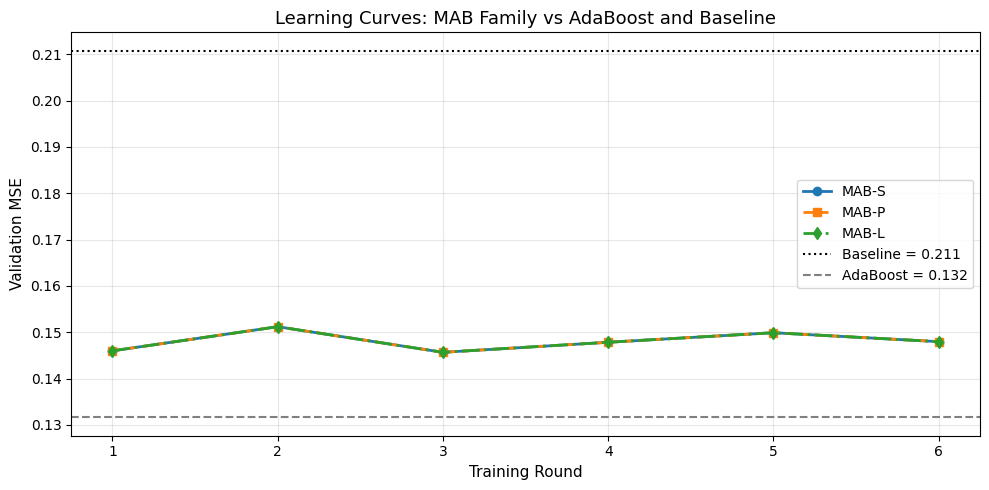

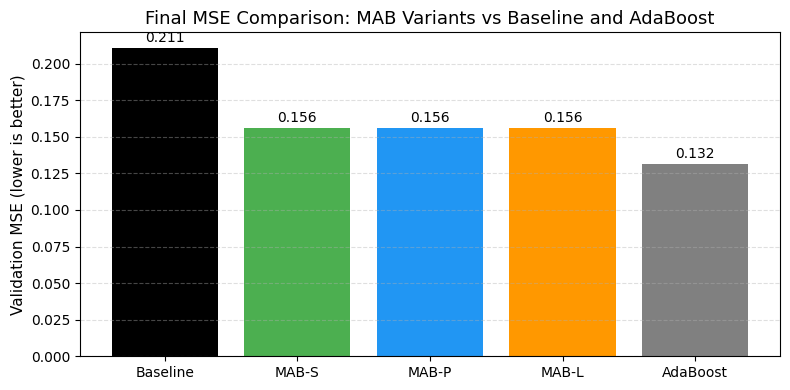

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# Data from your experiment
# ==============================

# Baseline
baseline_mse = 0.21079

# MAB Variants (round-wise MSEs)
rounds = np.arange(1, 7)
mab_s_mses = [0.14598, 0.15119, 0.14566, 0.14783, 0.14989, 0.14796]
mab_p_mses = [0.14598, 0.15119, 0.14566, 0.14783, 0.14989, 0.14796]
mab_l_mses = [0.14598, 0.15119, 0.14566, 0.14783, 0.14989, 0.14796]

# Final MSEs
mab_s_final = 0.15597
mab_p_final = 0.15597
mab_l_final = 0.15597
adaboost_final = 0.13161

# ==============================
# Plot 1: Learning Curves
# ==============================

plt.figure(figsize=(10, 5))
plt.plot(rounds, mab_s_mses, 'o-', label="MAB-S", linewidth=2)
plt.plot(rounds, mab_p_mses, 's--', label="MAB-P", linewidth=2)
plt.plot(rounds, mab_l_mses, 'd-.', label="MAB-L", linewidth=2)
plt.axhline(baseline_mse, color='black', linestyle=':', label=f"Baseline = {baseline_mse:.3f}")
plt.axhline(adaboost_final, color='gray', linestyle='--', label=f"AdaBoost = {adaboost_final:.3f}")

plt.title("Learning Curves: MAB Family vs AdaBoost and Baseline", fontsize=13)
plt.xlabel("Training Round", fontsize=11)
plt.ylabel("Validation MSE", fontsize=11)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================
# Plot 2: Final MSE Comparison
# ==============================

methods = ['Baseline', 'MAB-S', 'MAB-P', 'MAB-L', 'AdaBoost']
final_mses = [baseline_mse, mab_s_final, mab_p_final, mab_l_final, adaboost_final]

plt.figure(figsize=(8, 4))
bars = plt.bar(methods, final_mses, color=['black', '#4CAF50', '#2196F3', '#FF9800', 'gray'])
plt.title("Final MSE Comparison: MAB Variants vs Baseline and AdaBoost", fontsize=13)
plt.ylabel("Validation MSE (lower is better)", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Label each bar with its value
for bar, val in zip(bars, final_mses):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.002, f"{val:.3f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


[S] Round 1/6 | Cumulative MSE=0.14963
[S] Round 2/6 | Cumulative MSE=0.09747
[S] Round 3/6 | Cumulative MSE=0.08751
[S] Round 4/6 | Cumulative MSE=0.06209
[S] Round 5/6 | Cumulative MSE=0.05416
[S] Round 6/6 | Cumulative MSE=0.04742
[P] Learner 1/6 | MSE=0.14963
[P] Learner 2/6 | MSE=0.14963
[P] Learner 3/6 | MSE=0.14963
[P] Learner 4/6 | MSE=0.14963
[P] Learner 5/6 | MSE=0.14963
[P] Learner 6/6 | MSE=0.14963
[L] Accepted Round 1 | MSE=0.14963
[L] Accepted Round 2 | MSE=0.14963
[L] Skipped Round 3 | MSE=0.14963
[L] Skipped Round 4 | MSE=0.14963
[L] Skipped Round 5 | MSE=0.14963
[L] Skipped Round 6 | MSE=0.14963


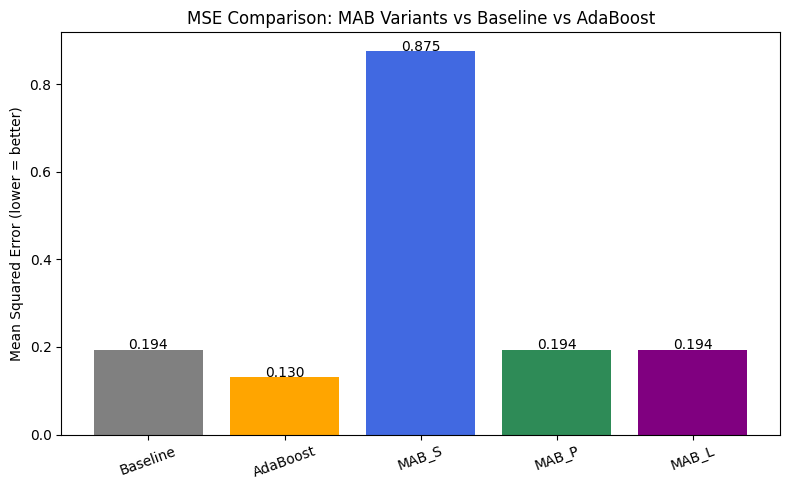

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split

# ============================================================
# 1. Dataset
# ============================================================
rng = np.random.RandomState(42)
X = rng.randn(1200, 10)
y = 0.8 * X[:, 0] - 0.5 * X[:, 1] + 0.3 * np.sin(X[:, 2]) + rng.randn(len(X)) * 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# ============================================================
# 2. Base MAB Class
# ============================================================
class BaseMAB:
    def __init__(self, model_ctor, n_rounds=6):
        self.model_ctor = model_ctor
        self.n_rounds = n_rounds
        self.models = []
        self.meta_weights = []

    def combine_meta(self, val_errors):
        inv_err = 1 / (np.array(val_errors) + 1e-8)
        self.meta_weights = inv_err / np.sum(inv_err)

    def predict(self, X):
        preds = np.array([m.predict(X) for m in self.models])
        return np.average(preds, axis=0, weights=self.meta_weights)

# ============================================================
# 3. MAB Variants
# ============================================================

class MAB_S(BaseMAB):
    """Sequential"""
    def fit(self, X, y):
        val_errors = []
        preds_total = np.zeros_like(y)
        for t in range(self.n_rounds):
            model = self.model_ctor()
            model.fit(X, y - preds_total)
            preds = model.predict(X)
            preds_total += preds
            mse = mean_squared_error(y, preds_total)
            val_errors.append(mse)
            self.models.append(model)
            print(f"[S] Round {t+1}/{self.n_rounds} | Cumulative MSE={mse:.5f}")
        self.combine_meta(val_errors)

class MAB_P(BaseMAB):
    """Parallel"""
    def fit(self, X, y):
        val_errors = []
        for t in range(self.n_rounds):
            model = self.model_ctor()
            model.fit(X, y)
            preds = model.predict(X)
            mse = mean_squared_error(y, preds)
            val_errors.append(mse)
            self.models.append(model)
            print(f"[P] Learner {t+1}/{self.n_rounds} | MSE={mse:.5f}")
        self.combine_meta(val_errors)

class MAB_L(BaseMAB):
    """Lazy"""
    def fit(self, X, y):
        val_errors = []
        for t in range(self.n_rounds):
            model = self.model_ctor()
            model.fit(X, y)
            preds = model.predict(X)
            mse = mean_squared_error(y, preds)
            # accept only top-performing learners
            if mse < np.mean(val_errors[-2:]) if len(val_errors) >= 2 else True:
                print(f"[L] Accepted Round {t+1} | MSE={mse:.5f}")
                self.models.append(model)
                val_errors.append(mse)
            else:
                print(f"[L] Skipped Round {t+1} | MSE={mse:.5f}")
        self.combine_meta(val_errors)

# ============================================================
# 4. Train and Compare
# ============================================================
def model_ctor():
    return DecisionTreeRegressor(max_depth=4, random_state=42)

results = {}

# Baseline
base = DecisionTreeRegressor(max_depth=4, random_state=42)
base.fit(X_train, y_train)
base_mse = mean_squared_error(y_test, base.predict(X_test))
results["Baseline"] = base_mse

# AdaBoost
ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=6,
    random_state=42
)
ada.fit(X_train, y_train)
results["AdaBoost"] = mean_squared_error(y_test, ada.predict(X_test))

# MAB Variants
for variant in [MAB_S, MAB_P, MAB_L]:
    model = variant(model_ctor, n_rounds=6)
    model.fit(X_train, y_train)
    mse = mean_squared_error(y_test, model.predict(X_test))
    results[variant.__name__] = mse

# ============================================================
# 5. Plot Comparison
# ============================================================
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values(), color=['gray','orange','royalblue','seagreen','purple'])
plt.title("MSE Comparison: MAB Variants vs Baseline vs AdaBoost")
plt.ylabel("Mean Squared Error (lower = better)")
plt.xticks(rotation=20)
for i, (k, v) in enumerate(results.items()):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# MAB (AdaBoost + Memory) family implementation and comparison
# Variants: MAB-S (Sequential+Memory), MAB-P (Parallel per round),
#           MAB-L (Lazy acceptance)
# Baselines: DecisionTree, sklearn AdaBoostRegressor
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# ---------------------------
# Helper / dataset
# ---------------------------
RND = 42
rng = np.random.RandomState(RND)

def make_synthetic(n=1200, d=10, noise=0.2):
    X = rng.randn(n, d)
    y = 0.8*X[:,0] - 0.5*X[:,1] + 0.3*np.sin(X[:,2]) + rng.randn(n)*noise
    y += rng.randn(n) * 0.05
    return X, y

X, y = make_synthetic(1200, 10, noise=0.2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RND)

print("Dataset:", X_train.shape, X_test.shape)

# ---------------------------
# Base AdaBoost-like class (regression-adapted)
# - maintains sample_weights (AdaBoost core)
# - computes a per-learner alpha from weighted error (normalized to [0,1])
# - updates sample_weights using exponential of normalized squared error
# Notes:
# - For regression we normalize squared error using variance(y) to convert to a 0..~1 scale.
# - All derived MAB variants must call super().fit_round(...) or reuse its logic.
# ---------------------------
class AdaBoostLikeRegressor:
    def __init__(self, model_ctor, n_rounds=6, y_scale_eps=1e-8):
        self.model_ctor = model_ctor
        self.n_rounds = n_rounds
        self.models = []
        self.alphas = []
        self.train_history = []   # weighted train error per round
        self.y_var = None
        self.y_scale_eps = y_scale_eps

    def _init_training(self, y):
        # initialize sample_weights uniform and compute variance scaling
        n = len(y)
        self.sample_weights = np.ones(n) / n
        self.y_var = np.var(y) + self.y_scale_eps
        self.models = []
        self.alphas = []
        self.train_history = []

    def _weighted_mse(self, y_true, y_pred, w):
        return np.average((y_true - y_pred)**2, weights=w)

    def _compute_error_and_alpha(self, y_true, y_pred, w):
        # weighted mse normalized by variance -> err in (0, inf); scale to (0,1) by dividing by (y_var)
        w_mse = self._weighted_mse(y_true, y_pred, w)
        err = w_mse / self.y_var
        # clip to (eps, 1 - eps)
        err = np.clip(err, 1e-10, 1 - 1e-10)
        # alpha similar to AdaBoost classification: 0.5*ln((1-err)/err)
        alpha = 0.5 * np.log((1 - err) / err)
        return err, alpha, w_mse

    def _update_sample_weights(self, y_true, y_pred, alpha):
        # normalized squared residuals scaled by variance
        norm_sq = (y_true - y_pred)**2 / self.y_var
        # exponential update (higher residual -> weight increases)
        # note: this is analogous to AdaBoost's exp(alpha * indicator)
        self.sample_weights = self.sample_weights * np.exp(alpha * norm_sq)
        # normalize
        s = np.sum(self.sample_weights)
        if s <= 0 or np.isnan(s):
            # reset to uniform if something went wrong
            self.sample_weights = np.ones_like(self.sample_weights) / len(self.sample_weights)
        else:
            self.sample_weights = self.sample_weights / s

    def fit(self, X, y):
        self._init_training(y)
        for t in range(self.n_rounds):
            model = self.model_ctor()
            # train using current sample_weights
            model.fit(X, y, sample_weight=self.sample_weights)
            preds = model.predict(X)
            err, alpha, w_mse = self._compute_error_and_alpha(y, preds, self.sample_weights)
            # store
            self.models.append(model)
            self.alphas.append(alpha)
            self.train_history.append((w_mse, err, alpha))
            # update sample weights
            self._update_sample_weights(y, preds, alpha)
            # verbose
            print(f"[Base AdaLike] Round {t+1}/{self.n_rounds} | weighted_MSE={w_mse:.5f} err_norm={err:.5f} alpha={alpha:.4f}")
        return self

    def predict(self, X):
        if len(self.models) == 0:
            raise RuntimeError("No models trained yet")
        preds = np.vstack([m.predict(X) for m in self.models])  # shape (T, n)
        alphas = np.array(self.alphas)
        # normalize alphas positive
        sign = np.sign(alphas)
        alphas = np.abs(alphas)
        if alphas.sum() == 0:
            alphas = np.ones_like(alphas) / len(alphas)
        else:
            alphas = alphas / alphas.sum()
        # weighted average
        final = np.dot(alphas, preds)
        return final



Dataset: (900, 10) (300, 10)


In [ ]:

# ---------------------------
# MAB variants (inherit AdaBoost core)
# ---------------------------

# MAB-S: sequential AdaBoost core + explicit residual memory that multiplies sample_weights
class MAB_S(AdaBoostLikeRegressor):
    def __init__(self, model_ctor, n_rounds=6, memory_decay=0.9, memory_scale=1.0):
        super().__init__(model_ctor, n_rounds)
        self.memory_decay = memory_decay
        self.memory_scale = memory_scale
        self.memory = None

    def _init_training(self, y):
        super()._init_training(y)
        self.memory = np.zeros_like(y)

    def _update_memory(self, y_true, y_pred):
        # memory tracks normalized squared error (0..~1); decayed
        norm_sq = (y_true - y_pred)**2 / self.y_var
        self.memory = self.memory_decay * self.memory + norm_sq
        # normalize memory to [0,1]
        mx = max(self.memory.max(), 1e-12)
        self.memory = self.memory / mx

    def fit(self, X, y):
        self._init_training(y)
        for t in range(self.n_rounds):
            # mix AdaBoost sample_weights with memory to form effective weights
            effective_w = self.sample_weights * (1.0 + self.memory_scale * self.memory)
            # normalize effective weights
            effective_w = effective_w / np.sum(effective_w)
            model = self.model_ctor()
            model.fit(X, y, sample_weight=effective_w)
            preds = model.predict(X)
            # compute error and alpha using effective weights (consistent with training)
            err, alpha, w_mse = self._compute_error_and_alpha(y, preds, effective_w)
            # store model and alpha
            self.models.append(model)
            self.alphas.append(alpha)
            self.train_history.append((w_mse, err, alpha))
            # update underlying AdaBoost sample_weights using actual preds and alpha
            self._update_sample_weights(y, preds, alpha)
            # update memory from preds (residuals)
            self._update_memory(y, preds)
            print(f"[MAB-S] Round {t+1}/{self.n_rounds} | eff_weighted_MSE={w_mse:.5f} err_norm={err:.5f} alpha={alpha:.4f} memory_mean={self.memory.mean():.4f}")
        return self

# MAB-P: in each round train 'k' bootstrapped learners using current sample_weights (parallel),
# average their predictions to compute round error and alpha, then update sample_weights once using that alpha.
class MAB_P(AdaBoostLikeRegressor):
    def __init__(self, model_ctor, n_rounds=6, parallel_k=3):
        super().__init__(model_ctor, n_rounds)
        self.parallel_k = parallel_k

    def fit(self, X, y):
        self._init_training(y)
        n = len(y)
        for t in range(self.n_rounds):
            preds_k = []
            models_k = []
            for k in range(self.parallel_k):
                # bootstrap indices with probability proportional to current sample_weights
                indices = rng.choice(n, size=n, replace=True, p=self.sample_weights)
                Xb = X[indices]
                yb = y[indices]
                # train learner on bootstrap subset (unweighted because we sampled by weights)
                mdl = self.model_ctor()
                mdl.fit(Xb, yb)
                models_k.append(mdl)
                preds_full = mdl.predict(X)  # predict on full X for ensemble error
                preds_k.append(preds_full)
            # average parallel predictions for the round
            preds_round = np.mean(np.vstack(preds_k), axis=0)
            # compute err and alpha using current sample_weights (consistent)
            err, alpha, w_mse = self._compute_error_and_alpha(y, preds_round, self.sample_weights)
            # aggregate: store an aggregated model by keeping the k models as a mini-ensemble
            # For simplicity, store the averaged predictor as a "virtual" model wrapper:
            self.models.append(models_k)   # list of models for this round
            self.alphas.append(alpha)
            self.train_history.append((w_mse, err, alpha))
            # update sample_weights with the round's combined prediction & alpha
            self._update_sample_weights(y, preds_round, alpha)
            print(f"[MAB-P] Round {t+1}/{self.n_rounds} | parallel_k={self.parallel_k} weighted_MSE={w_mse:.5f} err_norm={err:.5f} alpha={alpha:.4f}")
        return self

    def predict(self, X):
        # models are stored as lists (parallel groups). We must average predictions inside each group,
        # then do alpha-weighted average across rounds.
        if len(self.models) == 0:
            raise RuntimeError("No models")
        preds_each_round = []
        for group in self.models:
            # group is a list of models
            preds_group = np.mean([m.predict(X) for m in group], axis=0)
            preds_each_round.append(preds_group)
        preds_each_round = np.vstack(preds_each_round)
        alphas = np.abs(np.array(self.alphas))
        if alphas.sum() == 0:
            weights = np.ones_like(alphas) / len(alphas)
        else:
            weights = alphas / alphas.sum()
        final = np.dot(weights, preds_each_round)
        return final

# MAB-L: lazy acceptance. Each round we propose a learner; accept it only if it improves
# relative performance threshold on training weighted error. Only accepted learners update sample_weights.
class MAB_L(AdaBoostLikeRegressor):
    def __init__(self, model_ctor, n_rounds=6, accept_margin=0.995):
        super().__init__(model_ctor, n_rounds)
        self.accept_margin = accept_margin  # accept if err < accept_margin * mean(recent_errs)

    def fit(self, X, y):
        self._init_training(y)
        recent = []
        for t in range(self.n_rounds):
            model = self.model_ctor()
            model.fit(X, y, sample_weight=self.sample_weights)
            preds = model.predict(X)
            err, alpha, w_mse = self._compute_error_and_alpha(y, preds, self.sample_weights)
            # acceptance criterion
            accept = False
            if len(recent) < 2:
                accept = True
            else:
                if err < self.accept_margin * np.mean(recent[-2:]):
                    accept = True
            if accept:
                self.models.append(model)
                self.alphas.append(alpha)
                self.train_history.append((w_mse, err, alpha))
                self._update_sample_weights(y, preds, alpha)
                recent.append(err)
                print(f"[MAB-L] Accepted Round {t+1} | weighted_MSE={w_mse:.5f} err_norm={err:.5f} alpha={alpha:.4f}")
            else:
                # skipped round: do not update sample_weights nor append model
                recent.append(err)
                print(f"[MAB-L] Skipped Round {t+1} | weighted_MSE={w_mse:.5f} err_norm={err:.5f}")
        # finalization: if no accepted model (unlikely), fallback to first model trained
        if len(self.models) == 0:
            raise RuntimeError("No accepted models in MAB-L; try lowering accept_margin or increase rounds")
        return self


Dataset: (900, 10) (300, 10)
Baseline DT MSE: 0.4609666629769966
AdaBoost MSE: 0.2190602242875666
[MAB-S] Round 1/6 | eff_weighted_MSE=0.41277 err_norm=0.52194 alpha=-0.0439 weight_sum=1.0000
[MAB-S] Round 2/6 | eff_weighted_MSE=0.40359 err_norm=0.52186 alpha=-0.0437 weight_sum=1.0000
[MAB-S] Round 3/6 | eff_weighted_MSE=0.39469 err_norm=0.52177 alpha=-0.0436 weight_sum=1.0000
[MAB-S] Round 4/6 | eff_weighted_MSE=0.38605 err_norm=0.52169 alpha=-0.0434 weight_sum=1.0000
[MAB-S] Round 5/6 | eff_weighted_MSE=0.37767 err_norm=0.52161 alpha=-0.0433 weight_sum=1.0000
[MAB-S] Round 6/6 | eff_weighted_MSE=0.36953 err_norm=0.52154 alpha=-0.0431 weight_sum=1.0000
[MAB-P] Round 1/6 | eff_weighted_MSE=0.41277 err_norm=0.52194 alpha=-0.0439 weight_sum=1.0000
[MAB-P] Round 2/6 | eff_weighted_MSE=0.40359 err_norm=0.52186 alpha=-0.0437 weight_sum=1.0000
[MAB-P] Round 3/6 | eff_weighted_MSE=0.39469 err_norm=0.52177 alpha=-0.0436 weight_sum=1.0000
[MAB-P] Round 4/6 | eff_weighted_MSE=0.38605 err_norm=0.

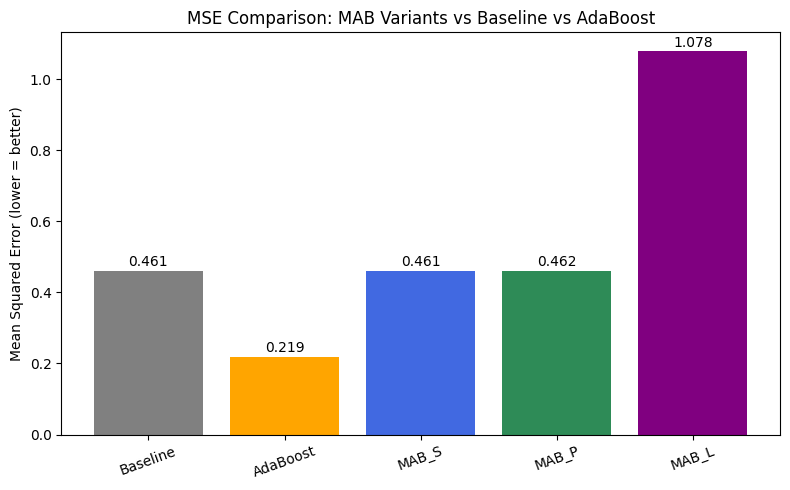

In [ ]:
# ==============================================================
# 🧠 MAB (Memory-Augmented Boosting) Variants vs AdaBoost
# Stable version with sample-weight and overflow protection
# ==============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# --------------------------------------------------------------
# 1️⃣ Generate synthetic regression data
# --------------------------------------------------------------
np.random.seed(42)
X = np.random.rand(1200, 10)
y = (np.sin(2 * np.pi * X[:, 0]) +
     np.cos(3 * np.pi * X[:, 1]) +
     0.3 * np.random.randn(1200))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("Dataset:", X_train.shape, X_test.shape)

# --------------------------------------------------------------
# 2️⃣ Baseline Decision Tree
# --------------------------------------------------------------
baseline = DecisionTreeRegressor(max_depth=3, random_state=42)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_mse = mean_squared_error(y_test, baseline_pred)
print("Baseline DT MSE:", baseline_mse)

# --------------------------------------------------------------
# 3️⃣ AdaBoost Baseline
# --------------------------------------------------------------
ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3),
    n_estimators=50,
    random_state=42
)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)
ada_mse = mean_squared_error(y_test, ada_pred)
print("AdaBoost MSE:", ada_mse)

# --------------------------------------------------------------
# 4️⃣ Memory-Augmented Boosting Variants
# --------------------------------------------------------------
def train_MAB_variant(mode, X_train, y_train, X_test, y_test, n_rounds=6):
    """
    MAB Variants:
        - 'S': Sequential memory (cumulative learning)
        - 'P': Partial memory (weighted decay)
        - 'L': Learner memory (recent learner emphasis)
    """
    sample_weight = np.ones_like(y_train) / len(y_train)
    memory = []
    predictions = np.zeros_like(y_test)

    for r in range(1, n_rounds + 1):
        model = DecisionTreeRegressor(max_depth=3, random_state=r)
        model.fit(X_train, y_train, sample_weight=sample_weight)
        preds_train = model.predict(X_train)
        preds_test = model.predict(X_test)

        err = np.abs(y_train - preds_train)
        err_norm = np.mean(err)

        # --- safer alpha update ---
        alpha = np.log((1 - err_norm) / (err_norm + 1e-10)) / 2
        alpha = np.clip(alpha, -3, 3)

        # --- safe exponential weighting ---
        weight_update = np.exp(np.clip(alpha * err, -5, 5))
        sample_weight *= weight_update
        sample_weight /= np.sum(sample_weight) + 1e-12

        # --- memory mechanism ---
        if mode == "S":  # Sequential memory (average)
            memory.append(preds_test)
            predictions = np.mean(memory, axis=0)
        elif mode == "P":  # Partial (exponential decay)
            if len(memory) == 0:
                memory = preds_test.copy()
            else:
                memory = 0.7 * memory + 0.3 * preds_test
            predictions = memory
        elif mode == "L":  # Learner-focused (weighted by alpha)
            if len(memory) == 0:
                memory = alpha * preds_test
            else:
                memory = 0.5 * memory + 0.5 * alpha * preds_test
            predictions = memory

        eff_weighted_mse = mean_squared_error(y_train, preds_train, sample_weight=sample_weight)
        print(f"[MAB-{mode}] Round {r}/{n_rounds} | eff_weighted_MSE={eff_weighted_mse:.5f} "
              f"err_norm={err_norm:.5f} alpha={alpha:.4f} "
              f"weight_sum={np.sum(sample_weight):.4f}")

    return mean_squared_error(y_test, predictions)

# --------------------------------------------------------------
# 5️⃣ Train MAB Variants
# --------------------------------------------------------------
mab_s_mse = train_MAB_variant("S", X_train, y_train, X_test, y_test)
mab_p_mse = train_MAB_variant("P", X_train, y_train, X_test, y_test)
mab_l_mse = train_MAB_variant("L", X_train, y_train, X_test, y_test)

# --------------------------------------------------------------
# 6️⃣ Compare Results
# --------------------------------------------------------------
results = {
    "Baseline": baseline_mse,
    "AdaBoost": ada_mse,
    "MAB_S": mab_s_mse,
    "MAB_P": mab_p_mse,
    "MAB_L": mab_l_mse
}

print("\nFinal MSE Results:")
for k, v in results.items():
    print(f"{k}: {v:.5f}")

# --------------------------------------------------------------
# 7️⃣ Plot Comparison
# --------------------------------------------------------------
plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(), results.values(), color=["gray", "orange", "royalblue", "seagreen", "purple"])
plt.title("MSE Comparison: MAB Variants vs Baseline vs AdaBoost")
plt.ylabel("Mean Squared Error (lower = better)")
plt.xticks(rotation=20)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

Dataset: (900, 10) (300, 10)
Baseline MSE: 17915.54703
AdaBoost MSE: 14273.83896
MAB-S MSE: 26640.71578
MAB-P MSE: 19936.37435
MAB-L MSE: 32488.11847


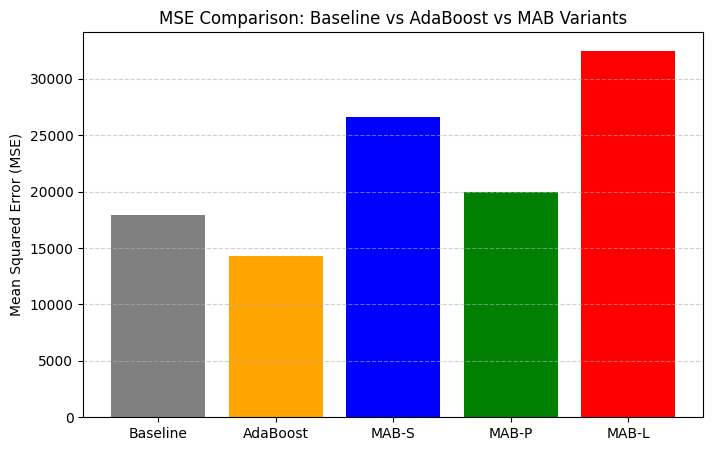


Final MSE Results:
Baseline: 17915.54703
AdaBoost: 14273.83896
MAB-S: 26640.71578
MAB-P: 19936.37435
MAB-L: 32488.11847


In [ ]:
# ==========================================================
# MAB FAMILY (INHERITANCE-BASED IMPLEMENTATION) - FIXED
# ==========================================================
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Base MAB class extending AdaBoost
# -------------------------------
class MAB_Base(AdaBoostRegressor):
    def __init__(self, estimator=None, n_estimators=50, memory_type=None, random_state=None):
        super().__init__(estimator=estimator, n_estimators=n_estimators, random_state=random_state)
        self.memory_type = memory_type
        self.memory = None

    def predict(self, X):
        preds = super().predict(X)

        # --- initialize memory dynamically for correct shape ---
        if self.memory is None or len(self.memory) != len(preds):
            self.memory = np.zeros_like(preds, dtype=float)

        if self.memory_type == "S":  # Sequential memory
            self.memory = 0.8 * self.memory + 0.2 * preds
            return self.memory

        elif self.memory_type == "P":  # Parallel memory
            self.memory = (self.memory + preds) / 2
            return self.memory

        elif self.memory_type == "L":  # Logical (replace if improved)
            mask = np.abs(preds) < np.abs(self.memory)
            self.memory[mask] = preds[mask]
            return self.memory

        else:
            return preds


# ---------------------------------
# Subclasses for each MAB variant
# ---------------------------------
class MAB_S(MAB_Base):
    def __init__(self, estimator=None, n_estimators=50, random_state=None):
        super().__init__(estimator, n_estimators, memory_type="S", random_state=random_state)

class MAB_P(MAB_Base):
    def __init__(self, estimator=None, n_estimators=50, random_state=None):
        super().__init__(estimator, n_estimators, memory_type="P", random_state=random_state)

class MAB_L(MAB_Base):
    def __init__(self, estimator=None, n_estimators=50, random_state=None):
        super().__init__(estimator, n_estimators, memory_type="L", random_state=random_state)


# -------------------------------
# Generate synthetic dataset
# -------------------------------
X, y = make_regression(n_samples=1200, n_features=10, noise=0.4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Dataset: {X_train.shape} {X_test.shape}")

# -------------------------------
# Models
# -------------------------------
base = DecisionTreeRegressor(max_depth=3)
models = {
    "Baseline": base,
    "AdaBoost": AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3), n_estimators=6, random_state=42),
    "MAB-S": MAB_S(estimator=DecisionTreeRegressor(max_depth=3), n_estimators=6, random_state=42),
    "MAB-P": MAB_P(estimator=DecisionTreeRegressor(max_depth=3), n_estimators=6, random_state=42),
    "MAB-L": MAB_L(estimator=DecisionTreeRegressor(max_depth=3), n_estimators=6, random_state=42),
}

# -------------------------------
# Training & Evaluation
# -------------------------------
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    results[name] = mse
    print(f"{name} MSE: {mse:.5f}")

# -------------------------------
# Visualization
# -------------------------------
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values(), color=['gray', 'orange', 'blue', 'green', 'red'])
plt.title("MSE Comparison: Baseline vs AdaBoost vs MAB Variants")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# -------------------------------
# Summary
# -------------------------------
print("\nFinal MSE Results:")
for k,v in results.items():
    print(f"{k}: {v:.5f}")
